In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [3]:
def biseccion(function, xu, xl, error):
    if function(xu)*function(xl) > 0: return None

# Inicializar el dataframe
    df = pd.DataFrame(columns=["xu", "xl", "xr", "f(xu)", "f(xl)", "f(xr)", "f(xl)f(xr)", "Error"])

    xr = (xl + xu)/2
    fxu = function(xu)
    fxl = function(xl)
    fxr = function(xr)
    
    fxl_xu = fxl*fxr
    error_actual = xu-xr

    df.loc[len(df)] = [xu, xl, xr, fxu, fxl, fxr, fxl_xu, error_actual]

    while(error_actual > error):
        if fxl_xu < 0:
            xu = xr
        elif fxl_xu > 0:
            xl = xr
        elif fxl_xu == 0:
            return xr, df
        
        xr = (xl + xu)/2
        fxu = function(xu)
        fxl = function(xl)
        fxr = function(xr)
    
        fxl_xu = fxl*fxr
        error_actual = xu-xr

        df.loc[len(df)] = [xu, xl, xr, fxu, fxl, fxr, fxl_xu, error_actual]

    return xr, df

In [4]:
f = lambda x: 3*x**2 - 120*x + 100
error = 0.001
xr, df = biseccion(f, 45, 35, error)

In [5]:
df

,xu,xl,xr,f(xu),f(xl),f(xr),f(xl)f(xr),Error
0,45.000000,35.000000,40.000000,775.000000,-425.000000,100.000000,-42500.000000,5.000000
1,40.000000,35.000000,37.500000,100.000000,-425.000000,-181.250000,77031.250000,2.500000
2,40.000000,37.500000,38.750000,100.000000,-181.250000,-45.312500,8212.890625,1.250000
3,40.000000,38.750000,39.375000,100.000000,-45.312500,26.171875,-1185.913086,0.625000
4,39.375000,38.750000,39.062500,26.171875,-45.312500,-9.863281,446.929932,0.312500
5,39.375000,39.062500,39.218750,26.171875,-9.863281,8.081055,-79.705715,0.156250
6,39.218750,39.062500,39.140625,8.081055,-9.863281,-0.909424,8.969903,0.078125
7,39.218750,39.140625,39.179688,8.081055,-0.909424,3.581238,-3.256863,0.039062
8,39.179688,39.140625,39.160156,3.581238,-0.909424,1.334763,-1.213865,0.019531
9,39.160156,39.140625,39.150391,1.334763,-0.909424,0.212383,-0.193146,0.009766


In [6]:
test = df.loc[:, ["xu", "xl"]].to_numpy()
    

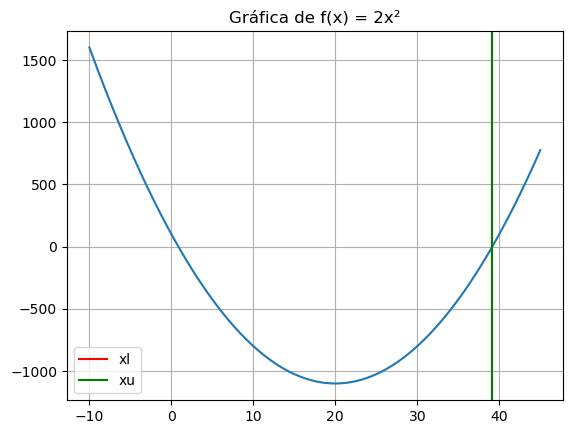

In [7]:
x = np.linspace(-10, 45, 400)
y = f(x)

for row in df.loc[:, ["xu", "xl"]].to_numpy():
    clear_output(wait=True)

    plt.figure()
    plt.plot(x, y)
    plt.axvline(x=row[1], color="red", label="xl")
    plt.axvline(x=row[0], color="green", label="xu")

    plt.title("Gráfica de f(x) = 2x²")
    plt.legend()
    plt.grid(True)
    plt.show()

    time.sleep(1)